# Readout under inter-run drift — TREX goes stale too  (experimental)

The sibling `Composite_drift.ipynb` showed that **static PEC** breaks under gate-noise drift: its
quasi-probability reps are built once, from nominal parameters, and go **stale**. Readout mitigation
has the *same* structure. **TREX** (Twirled Readout Error eXtinction) calibrates the twirled
eigenvalue $\lambda_w$ once and divides it out — so under **readout drift** its calibration goes stale
exactly like PEC's reps.

We compare three levels, all under a drifting readout, **measured on Aer with real shot noise**
(honest scatter / error bars):
- **noisy** — no readout mitigation (readout floor);
- **TREX static** — $\lambda_w$ calibrated once on the **nominal** readout, then frozen;
- **TREX adaptive** — $\lambda_w$ **recalibrated per run** on the current readout.

Recalibrating per run is the simplest form of *noise-model learning* — a concrete preview of the
re-learning step.

## 1. Setup

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

import sys
from pathlib import Path
for _cand in (Path.cwd(), Path.cwd() / "notebooks", *Path.cwd().parents):
    if (_cand / "qem" / "__init__.py").exists():
        if str(_cand) not in sys.path:
            sys.path.insert(0, str(_cand))
        break
from qem import *

warnings.filterwarnings("ignore")


def mirror_counts(backend, seed, shots):
    "Counts of mirror(seed) run on `backend` (gate noise + readout)."
    qc = make_benchmark_circuit(seed).copy(); qc.measure_all()
    return backend.run(qc, shots=shots).result().get_counts()


def calib_counts(readout, shots):
    "TREX calibration: |0...0> through the (twirled) readout -> <Z_w> = lambda_w."
    qc = QuantumCircuit(N_QUBITS); qc.measure_all()
    return AerSimulator(noise_model=readout.readout_noise_model()).run(qc, shots=shots).result().get_counts()


def scaled_readout(scale):
    "Readout drifted to `scale` x nominal (clipped to a valid channel)."
    clip = lambda p: min(scale * p, 0.49)
    return ReadoutSpec("drift", tuple(clip(p) for p in READOUT_REALISTIC.p0),
                       tuple(clip(p) for p in READOUT_REALISTIC.p1))


print("qem loaded. Nominal lambda_ZZ:", round(READOUT_REALISTIC.lambda_support((0, 1)), 4))
print("Twirl = simulate the SYMMETRISED channel:",
      READOUT_REALISTIC.twirled().p0, "== p1 (p_bar)")

qem loaded. Nominal lambda_ZZ: 0.9235
Twirl = simulate the SYMMETRISED channel: (0.0175, 0.0215) == p1 (p_bar)


## 2. TREX in one line, made experimental

Readout X-twirling symmetrises each qubit's $(p_0,p_1)$ so every $Z_w$ carries a clean eigenvalue

$$\lambda_w = \prod_{i\in w}\big(1 - p_{0,i} - p_{1,i}\big), \qquad
  \langle Z_w\rangle_{\text{noisy}} = \lambda_w^{\text{true}}\,\langle Z_w\rangle_{\text{ideal}}.$$

TREX divides $\langle Z_w\rangle$ by an **estimate** of $\lambda_w$; the regime is set by *which*
$\lambda_w$ it uses (drifted $\to$ adaptive, frozen nominal $\to$ static).

**Experimental realisation.** Twirling a bit-flip channel averages $(p_0,p_1)\to\bar p$, so instead of
per-shot X-twirls we simulate the **symmetrised** channel (`ReadoutSpec.twirled()`) directly — the raw
Aer counts *are* the twirled counts, **with real shot noise**. Both ingredients are measured:
- **execution** — mirror circuit through gate + twirled-drifted readout $\to \langle Z_w\rangle_{\text{exec}}$;
- **calibration** — $|0\dots0\rangle$ through the twirled readout $\to \langle Z_w\rangle = \lambda_w$.

Then $P(\text{target}) = 2^{-n}\sum_w (-1)^{t\cdot w}\,\langle Z_w\rangle_{\text{exec}}/\lambda_w^{\text{calib}}$.
(Mean matches the analytic helper, itself validated against mitiq's real TREX; see
`tests/smoke_drift_trex_exp.py`.)

## 3. Staleness scan (ideal gate) — how fast the residual grows, with error bars

Isolate the readout channel: an **ideal gate** (so a perfect method reaches exactly 1.0) and a readout
scaled to $s\times$ nominal. As $s$ grows, **static** TREX under-corrects (its frozen $\lambda_w$ is
too large) while **adaptive** TREX tracks and stays at 1.0; **noisy** is the readout floor.

$s$ is a **staleness axis, not a time axis.** This is a deterministic scan, *not* an OU trajectory:
each point isolates a **fixed** amount of calibration staleness, which is what makes the dependence
readable — a single OU realisation would mix a varying staleness into every run, and (being symmetric
about $\mu=1$) would average much of the bias away into variance.

So the scan measures a **transfer function**, not a session. The shaded band marks where the OU model
of `qem/drift.py` actually lives (`readout_scale`, $\sigma_{rel}=0.15$); the dashed line at $s=1.25$
marks the >25 % SPAM excursions reported on hardware (arXiv:2404.13269), which is what `sigma_rel` was
calibrated against. Everything to its right is a **stress test**, plotted on purpose so the slope is
visible — not a claim about typical operation.

s=1.00  noisy 0.961  static 0.998  adaptive 0.999


s=1.25  noisy 0.952  static 0.988  adaptive 1.001


s=1.50  noisy 0.942  static 0.978  adaptive 0.998


s=1.75  noisy 0.934  static 0.969  adaptive 0.994


s=2.00  noisy 0.923  static 0.957  adaptive 0.992


s=2.25  noisy 0.915  static 0.949  adaptive 1.003


s=2.50  noisy 0.904  static 0.937  adaptive 0.999


s=2.75  noisy 0.896  static 0.928  adaptive 0.991


s=3.00  noisy 0.885  static 0.917  adaptive 0.999


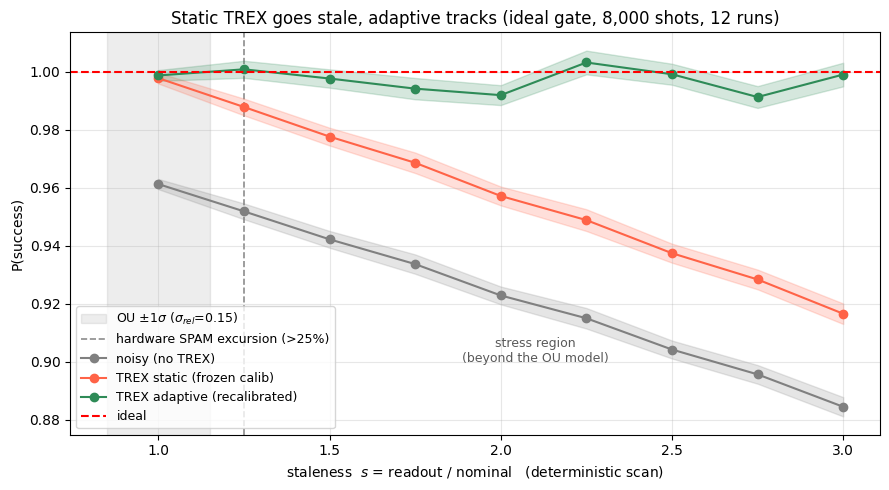


  s     static measured   predicted (1+r0)(1+r1)/4
 1.00           0.9978                   1.0000
 1.25           0.9878                   0.9899
 1.50           0.9776                   0.9798
 1.75           0.9686                   0.9698
 2.00           0.9572                   0.9598
 2.25           0.9488                   0.9499
 2.50           0.9374                   0.9400
 2.75           0.9284                   0.9302
 3.00           0.9166                   0.9204


In [2]:
SCALES = np.linspace(1.0, 3.0, 9)   # readout scaled to s x nominal (deterministic staleness scan)
SHOTS = 8_000                       # realistic per-run budget -> visible shot noise
N_REP = 12                          # runs (circuits) per point -> error bars
ideal = AerSimulator()
CALIB_STATIC = calib_counts(READOUT_REALISTIC.twirled(), SHOTS)  # frozen nominal calibration, once

res = {k: {"m": [], "e": []} for k in ["noisy", "static", "adaptive"]}
for sc in SCALES:
    ro = scaled_readout(sc)
    exec_bk = AerSimulator(noise_model=ro.twirled().readout_noise_model())  # ideal gate + twirled drift
    calib_adapt = calib_counts(ro.twirled(), SHOTS)                         # recalibrated for this drift
    calib_perfect = calib_counts(READOUT_PERFECT, SHOTS)                    # lambda = 1 (noisy)
    cols = {"noisy": [], "static": [], "adaptive": []}
    for rep in range(N_REP):
        ec, tgt = mirror_counts(exec_bk, rep, SHOTS), target_key(rep)
        cols["noisy"].append(trex_success_prob_experimental(ec, calib_perfect, tgt, SHOTS, SHOTS))
        cols["static"].append(trex_success_prob_experimental(ec, CALIB_STATIC, tgt, SHOTS, SHOTS))
        cols["adaptive"].append(trex_success_prob_experimental(ec, calib_adapt, tgt, SHOTS, SHOTS))
    for k in res:
        res[k]["m"].append(np.mean(cols[k])); res[k]["e"].append(np.std(cols[k]))
    print(f"s={sc:.2f}  noisy {res['noisy']['m'][-1]:.3f}  static {res['static']['m'][-1]:.3f}  "
          f"adaptive {res['adaptive']['m'][-1]:.3f}")

# Where the OU model of qem/drift.py actually lives, so the stress region is visibly labelled as such
# rather than passed off as typical. sigma_rel was itself calibrated against the >25% SPAM excursions
# of arXiv:2404.13269, i.e. s ~ 1.25 -- drawn as the dashed marker.
SIGMA_OU = DRIFT_DEFAULT.readout_scale.sigma_rel

style = {"noisy": ("gray", "noisy (no TREX)"), "static": ("tomato", "TREX static (frozen calib)"),
         "adaptive": ("seagreen", "TREX adaptive (recalibrated)")}
plt.figure(figsize=(9, 5))
plt.axvspan(1 - SIGMA_OU, 1 + SIGMA_OU, color="k", alpha=0.07, zorder=0,
            label=f"OU $\\pm1\\sigma$ ($\\sigma_{{rel}}$={SIGMA_OU})")
plt.axvline(1.25, ls="--", c="k", alpha=0.45, lw=1.2, zorder=1,
            label="hardware SPAM excursion (>25%)")
for k, (c, lab) in style.items():
    m, e = np.array(res[k]["m"]), np.array(res[k]["e"])
    plt.plot(SCALES, m, "o-", c=c, label=lab)
    plt.fill_between(SCALES, m - e, m + e, color=c, alpha=0.2)
plt.axhline(1.0, ls="--", c="r", lw=1.5, label="ideal")
plt.text(2.1, 0.90, "stress region\n(beyond the OU model)", fontsize=9, color="0.35", ha="center")
plt.xlabel("staleness  $s$ = readout / nominal   (deterministic scan)"); plt.ylabel("P(success)")
plt.title(f"Static TREX goes stale, adaptive tracks (ideal gate, {SHOTS:,} shots, {N_REP} runs)")
plt.legend(fontsize=9); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# The static curve is PREDICTED, not just measured: with an ideal gate the estimator is
# (1+r0)(1+r1)/4 with r_i = lambda_i(s)/lambda_i(1) -- no free parameter.
r = lambda i, s: ((1 - sum(p[i] for p in (scaled_readout(s).p0, scaled_readout(s).p1)))
                  / (1 - READOUT_REALISTIC.p0[i] - READOUT_REALISTIC.p1[i]))
print("\n  s     static measured   predicted (1+r0)(1+r1)/4")
for sc, m in zip(SCALES, res["static"]["m"]):
    print(f"{sc:5.2f}   {m:14.4f}   {(1 + r(0, sc)) * (1 + r(1, sc)) / 4:22.4f}")

## 4. Full stack under drift — realistic picture

Now the realistic model: composite **gate** noise (nominal) **+** a readout drifted to $2\times$ (a
plausible "stale-calibration moment"). Bars = mean over circuits, error bars $\pm 1\sigma$:
- **noisy** = gate + readout floor;
- **TREX static** = removes only what the frozen $\lambda_w$ predicts $\to$ partial;
- **TREX adaptive** = removes readout exactly $\to$ lands at the **gate floor** (gate noise remains).

Read the bars as **paired**: all three use the same circuits, so the $\pm1\sigma$ shown is dominated
by circuit-to-circuit variation of the composite gate noise (common mode), not by the effect under
study. The per-circuit differences resolve at tens of $\sigma$ — printed below the figure.

§5 then composes ZNE on top, which is what actually clears the gate floor.

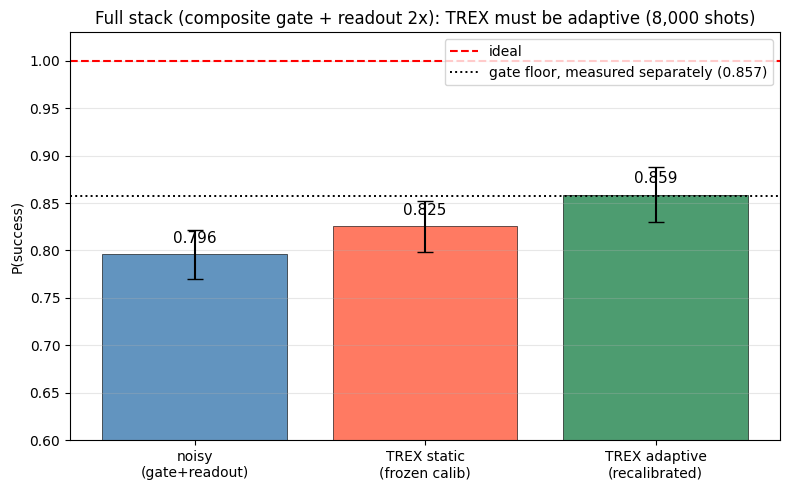

adaptive 0.8587  vs  independent gate floor 0.8573   |diff| 0.0014
paired adaptive - noisy    +0.0627 +- 0.0032   (68 sigma)
paired adaptive - static   +0.0333 +- 0.0017   (68 sigma)
paired   static - noisy    +0.0294 +- 0.0015   (68 sigma)


In [3]:
RO_BAD = scaled_readout(2.0)            # readout drifted to 2x nominal
SHOTS4, N_SEEDS4 = 8_000, 12
nm = SPEC_COMPOSITE.build_noise_model(); RO_BAD.twirled().add_readout_error(nm)
exec_bk = AerSimulator(noise_model=nm)  # composite gate + twirled 2x readout
CAL_PERFECT = calib_counts(READOUT_PERFECT, SHOTS4)
CAL_STATIC = calib_counts(READOUT_REALISTIC.twirled(), SHOTS4)  # frozen nominal
CAL_ADAPT = calib_counts(RO_BAD.twirled(), SHOTS4)              # recalibrated on 2x

cols = {"noisy": [], "static": [], "adaptive": []}
for s in range(N_SEEDS4):
    ec, tgt = mirror_counts(exec_bk, s, SHOTS4), target_key(s)
    cols["noisy"].append(trex_success_prob_experimental(ec, CAL_PERFECT, tgt, SHOTS4, SHOTS4))
    cols["static"].append(trex_success_prob_experimental(ec, CAL_STATIC, tgt, SHOTS4, SHOTS4))
    cols["adaptive"].append(trex_success_prob_experimental(ec, CAL_ADAPT, tgt, SHOTS4, SHOTS4))

# The gate floor must be measured INDEPENDENTLY (a gate-only backend, no readout at all). Drawing it
# at the adaptive mean would make "adaptive lands on the floor" true by construction; here it is a
# genuine prediction that the figure can falsify.
gate_bk = AerSimulator(noise_model=SPEC_COMPOSITE.build_noise_model())
gate_floor = float(np.mean([success_prob(gate_bk, s, SHOTS4) for s in range(N_SEEDS4)]))

labels = ["noisy\n(gate+readout)", "TREX static\n(frozen calib)", "TREX adaptive\n(recalibrated)"]
keys, colors = ["noisy", "static", "adaptive"], ["steelblue", "tomato", "seagreen"]
means = [np.mean(cols[k]) for k in keys]; errs = [np.std(cols[k]) for k in keys]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, means, yerr=errs, capsize=6, color=colors, alpha=0.85,
              edgecolor="black", linewidth=0.5)
for b, m in zip(bars, means):
    ax.text(b.get_x() + b.get_width() / 2, m + 0.012, f"{m:.3f}", ha="center", fontsize=11)
ax.axhline(1.0, ls="--", c="r", lw=1.5, label="ideal")
ax.axhline(gate_floor, ls=":", c="k", lw=1.4,
           label=f"gate floor, measured separately ({gate_floor:.3f})")
ax.set_ylabel("P(success)"); ax.set_ylim(0.6, 1.03)
ax.set_title(f"Full stack (composite gate + readout 2x): TREX must be adaptive ({SHOTS4:,} shots)")
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

print(f"adaptive {means[2]:.4f}  vs  independent gate floor {gate_floor:.4f}"
      f"   |diff| {abs(means[2] - gate_floor):.4f}")
# The three branches share circuits, so the seed spread above is COMMON MODE: compare per-circuit.
a = {k: np.array(cols[k]) for k in keys}
for hi, lo in (("adaptive", "noisy"), ("adaptive", "static"), ("static", "noisy")):
    d = a[hi] - a[lo]
    print(f"paired {hi:>8} - {lo:<8} {d.mean():+.4f} +- {d.std():.4f}"
          f"   ({abs(d.mean()) / (d.std() / np.sqrt(len(d))):.0f} sigma)")

## 5. TREX $\circ$ ZNE under drift — ZNE inherits a stale calibration

§4 stops at the gate floor. Composing **ZNE on top** is what clears it: TREX corrects the readout
inside the executor, the extrapolation removes the gate noise outside. On the *static* model
(`Composite_readout_TREX.ipynb` §6) that stack recovers $\approx 1.0$. The question here is what
**drift** does to it.

Two results, both visible on one figure:

**1. The ZNE-only floor deepens with drift.** Folding scales *gate* noise; the measurement error is
applied once regardless of depth, so ZNE extrapolates $\lambda_{\text{readout}}\cdot P_{\text{gate}}(\lambda)$
and stalls at $\lambda_{\text{readout}}$ itself — $\prod_i(1-\bar p_i)$, drawn as a reference line.
At nominal readout that floor sits near 0.98; at $2\times$ it drops to $\approx 0.92$. **The worse the
device drifts, the more indispensable TREX becomes** — the opposite of the naive intuition that a
zero-noise extrapolation would eventually clean everything up.

**2. ZNE does not rescue a stale calibration, it inherits it.** A frozen $\lambda_w$ introduces a
multiplicative factor $r_w = \lambda_w(t)/\lambda_w(0)$ that is *constant in the folding scale*, so the
extrapolation propagates it untouched all the way to $\lambda \to 0$. Static $\circ$ ZNE therefore
lands at $\approx r \times 1.0$, not at 1.0.

Both TREX branches use the **same estimator** and differ only by the calibration counts handed to it —
one controlled variable. (Mitiq's own TREX recalibrates itself and so cannot be made static; using it
for one branch and the counts path for the other would compare two implementations rather than two
calibration policies.) Staying on the counts path also drops the $\times$`num_randomizations` cost of
the mitiq route, which is what makes running TREX inside every scale factor cheap.

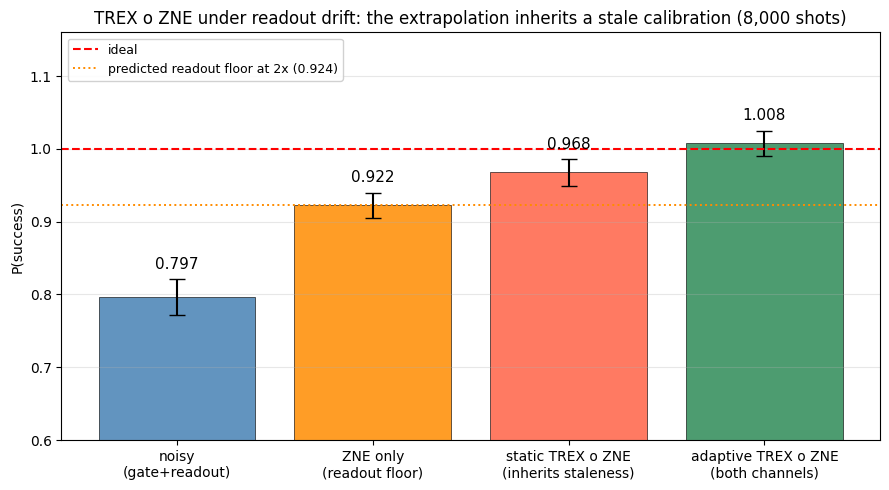

branch                   mean      std  n_fail
noisy                  0.7965   0.0242       0
ZNE only               0.9224   0.0176       0
static TREX o ZNE      0.9676   0.0186       0
adaptive TREX o ZNE    1.0076   0.0175       0

ZNE only 0.9224  vs  predicted readout floor 0.9235   -> folding does not scale readout
paired adaptive - static : +0.0400 +- 0.0202 over 12/12 circuits


In [4]:
from mitiq import zne
from mitiq.zne.inference import ExpFactory, ExtrapolationError
from mitiq.zne.scaling import fold_global

SF = SPEC_COMPOSITE_READOUT.scale_factors   # [1, 1.5, 2, 3, 5] -- 5 points for the free-asymptote fit


def zne_exp(circuit, executor):
    "Non-adaptive ExpFactory ZNE (free asymptote) -> NaN if the fit fails, as run_benchmark does."
    try:
        return zne.execute_with_zne(circuit, executor, scale_noise=fold_global,
                                    factory=ExpFactory(scale_factors=SF, asymptote=None))
    except ExtrapolationError:
        return float("nan")


def trex_zne_executor(backend, target, calib, shots):
    """Readout-corrected P(target) from counts, with a CHOSEN calibration -> composable with ZNE.

    Folding preserves the logical action, so `target` stays valid at every scale factor; and readout
    is applied once at measurement, so lambda_w is the same for the folded circuit as for the bare
    one. Swapping `calib` is therefore the ONLY difference between the static and adaptive branches.
    """
    def ex(circuit) -> float:
        qc = circuit.copy(); qc.measure_all()
        counts = backend.run(qc, shots=shots).result().get_counts()
        return trex_success_prob_experimental(counts, calib, target, shots, shots)
    return ex


rows = []
for s in range(N_SEEDS4):
    circ, tgt = make_benchmark_circuit(s), target_key(s)
    rows.append((
        success_prob(exec_bk, s, SHOTS4),                                    # noisy
        zne_exp(circ, mitiq_executor(exec_bk, s, SHOTS4)),                   # ZNE only -> readout floor
        zne_exp(circ, trex_zne_executor(exec_bk, tgt, CAL_STATIC, SHOTS4)),  # stale calib, propagated
        zne_exp(circ, trex_zne_executor(exec_bk, tgt, CAL_ADAPT, SHOTS4)),   # both channels cleared
    ))
arr = np.array(rows)

labels5 = ["noisy\n(gate+readout)", "ZNE only\n(readout floor)",
           "static TREX o ZNE\n(inherits staleness)", "adaptive TREX o ZNE\n(both channels)"]
colors5 = ["steelblue", "darkorange", "tomato", "seagreen"]
means5, errs5 = np.nanmean(arr, axis=0), np.nanstd(arr, axis=0)
# Predicted ZNE-only floor: the twirled channel is symmetric, so P(target) -> prod_i (1 - pbar_i)
# whatever the target bits. No fit, no free parameter.
ro_att = float(np.prod([1 - p for p in RO_BAD.twirled().p0]))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels5, means5, yerr=errs5, capsize=6, color=colors5, alpha=0.85,
              edgecolor="black", linewidth=0.5)
for b, m, e in zip(bars, means5, errs5):
    ax.text(b.get_x() + b.get_width() / 2, m + e + 0.014, f"{m:.3f}", ha="center", fontsize=11)
ax.axhline(1.0, ls="--", c="r", lw=1.5, label="ideal")
ax.axhline(ro_att, ls=":", c="darkorange", lw=1.4,
           label=f"predicted readout floor at 2x ({ro_att:.3f})")
ax.set_ylabel("P(success)"); ax.set_ylim(0.6, 1.16)
ax.set_title(f"TREX o ZNE under readout drift: the extrapolation inherits a stale calibration "
             f"({SHOTS4:,} shots)")
ax.legend(loc="upper left", fontsize=9, framealpha=0.9); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

# n_fail is reported, never silently dropped: a non-converging Exp fit is a property of the method
# on that circuit, not a missing measurement (same convention as run_benchmark).
print(f"{'branch':<20}{'mean':>9}{'std':>9}{'n_fail':>8}")
for j, lab in enumerate(l.splitlines()[0] for l in labels5):
    print(f"{lab:<20}{means5[j]:>9.4f}{errs5[j]:>9.4f}{int(np.isnan(arr[:, j]).sum()):>8}")
print(f"\nZNE only {means5[1]:.4f}  vs  predicted readout floor {ro_att:.4f}"
      f"   -> folding does not scale readout")
ok = ~np.isnan(arr[:, 3]) & ~np.isnan(arr[:, 2])
d = arr[ok, 3] - arr[ok, 2]
print(f"paired adaptive - static : {d.mean():+.4f} +- {d.std():.4f} over {ok.sum()}/{N_SEEDS4} circuits")

### Summary

TREX is a **static characterisation** just like PEC: it calibrates $\lambda_w$ once and divides it
out. Under **readout drift** that calibration goes stale, and static TREX **rebiases**. Three views,
each measured on Aer with real shot noise in both the execution *and* the calibration:

- **§3, staleness scan (ideal gate).** The static residual grows linearly with staleness — 0.002 at
  $s=1$, 0.081 at $s=3$ — and matches the parameter-free prediction $(1+r_0)(1+r_1)/4$. Adaptive stays
  flat at 1.0. The scan is a *transfer function*: the OU model of `qem/drift.py` lives near
  $s = 1 \pm 0.15$, and everything beyond is shown as a labelled stress region.
- **§4, full stack.** Adaptive TREX lands on the **independently measured** gate floor; static leaves
  roughly half the readout gap on the table at only $2\times$ drift.
- **§5, composed with ZNE.** Two things the composition reveals that §4 cannot: the ZNE-only floor
  **deepens** as the readout drifts (folding never scales the measurement error, so ZNE stalls at
  $\prod_i(1-\bar p_i)$), and a frozen $\lambda_w$ contributes a factor that is constant in the
  folding scale, so **the extrapolation propagates the staleness instead of curing it**.

Same lesson as the gate channel, now on the readout side: **every static characterisation — PEC's
reps and TREX's $\lambda_w$ — decays under non-stationary noise, and stacking a second mitigation on
top does not repair the first.** Recalibrating TREX per run is the simplest instance of the general
remedy: **re-learn the noise per run** (noise-model learning), then invert (PEC) or amplify (PEA) the
*learned* channel. That is the next step — and it is where the OU question "how often must one
recalibrate?" becomes the research question rather than a detail.